In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch
import time
import sys
sys.path.append('/home/jskinner1/scattering_transform')
import scattering
import ST
import math
import cmocean as cmo
import netCDF4 as nc

use torch backend


In [2]:
# Clear cache and import data 
torch.cuda.empty_cache()

# ------- Input data ------
datapath = "./JWS_turb_data/"
imin = 90  # starting index
imax = 100  # ending index
device = 'gpu'

with nc.Dataset(datapath + f"output_0{imin:03d}.nc", "r") as file:
    nx = file.dimensions["nx"].size
    ny = file.dimensions["nx"].size

image = np.zeros(((imax - imin + 1), nx, ny))

for i in range(imin, imax):
    filename = datapath + f"output_0{i:03d}.nc"  
    with nc.Dataset(filename, "r") as file:
        z = file.variables["z"][:]
        image[i - imin] = z

In [13]:
def smooth(image, j):
    M = image.shape[-2]
    N = image.shape[-1]
    X = np.arange(M)[:,None]
    Y = np.arange(N)[None,:]
    R2 = (X-M//2)**2 + (Y-N//2)**2
    weight_f = torch.from_numpy(np.fft.fftshift(np.exp(-0.5 * R2 / (M//(2**j)//2)**2))).cuda()
    image_smoothed = torch.fft.ifftn(
        torch.fft.fftn(
            image, dim=(-2,-1)
        ) * weight_f[None,:,:],
        dim=(-2,-1)
    )
    return image_smoothed.real

def image_synthesis(image, J, L, N_realization=1,
                    learnable_param_list = [(100, 1e-3)],
                    savedir = '',
                    device='cpu',
                    coef = 'PH',
                    random_seed = 987,
                    low_bound = -0.010,
                    high_bound = 1,
                    angular_factor = 1.0,
                    starting_power_factor = 1.0,
                    starting_image = None,
                    ST_norm = 1,
                    ST_algorithm = 'fast',
                    flip = True,
                    optim_mode='Adam',
                    mean_shift_init=1,
                    if_remove_edge=0,
                    filter='morlet'
):

    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    N_image = image.shape[0]
    M = image.shape[1]
    N = image.shape[2]
    if flip:
        flip_factor = 2
    else:
        flip_factor = 1
    if filter=='morlet':
        filters_set = ST.FiltersSet(
            M=M*flip_factor, N=N*flip_factor, J=J, L=L
        ).generate_morlet(
            if_save=False, save_dir=None, precision='single'
        )
    if filter=='BS':
        filters_set = ST.FiltersSet(
            M=M*flip_factor, N=N*flip_factor, J=J, L=L
        ).generate_bump_steerable(
            if_save=False, save_dir=None, precision='single'
        )
    if filter=='gau':
        filters_set = ST.FiltersSet(
            M=M*flip_factor, N=N*flip_factor, J=J, L=L
        ).generate_gau_steerable(
            if_save=False, save_dir=None, precision='single'
        )
    ST_calculator = ST.ST_2D(filters_set, J, L, device=device)
    
    bin_edges = np.linspace(150/(360/3.5), M/2*1.4, 7) # in unit of pixel in Fourier space
    bispectrum_calculator = ST.Bispectrum_Calculator(
        bin_edges, M*flip_factor, N*flip_factor, device=device
    )
    image_torch = torch.from_numpy(image).type(torch.FloatTensor) + 5
    if flip:
        image_flip_torch = torch.cat((
            torch.cat((
                image_torch, torch.flip(image_torch,[1])),1),
            torch.cat((
                torch.flip(image_torch,[2]), torch.flip(image_torch,[1,2])),1)), 2
        )
    else:
        image_flip_torch = image_torch

    if device=='gpu':
        image_torch = image_torch.cuda()
        image_flip_torch = image_flip_torch.cuda()
    
    plt.imshow(image_flip_torch[0].cpu().detach().numpy()-5)
    plt.show()

    target_bi = bispectrum_calculator.forward(image_flip_torch)
    target_ST_all = ST_calculator.forward(
        image_flip_torch, J, L, 
        algorithm=ST_algorithm,
        pseudo_coef=1)
    target_PH_all = ST_calculator.phase_harmonics(
        image_flip_torch, J, L)
    target_mean = target_ST_all[0][:,0]
    target_ST = target_ST_all[0][:,1:]
    select = (target_ST[0]!=0)
    target_ST = target_ST.log()[:,select]
    target_H = target_ST_all[-2]
    select = (target_H[0]!=0)
    target_H = target_H.log()[:,select]
    if 'ST' in coef:
        if 'C' in coef:
            target_C01 = target_ST_all[-1]
            select_C01 = (target_C01[0]!=0)
            target_C01 = target_C01[:,select_C01]
    if 'PH' in coef:

        target_C01 = target_PH_all['C01_r']
        select_C01 = (target_C01[0]!=0)
        target_C01 = target_C01[:,select_C01]
        
        target_PH00 = target_PH_all['C00'].sum(-1)
        target_S1 = target_PH_all['S1'].sum(-1)

        target_PH11diag = target_PH_all['C11diag_r'].reshape((N_image,-1))
        select_PH11diag = (target_PH11diag[0]>-9999)
        target_PH11diag = target_PH11diag[:,select_PH11diag]

        target_PH11 = target_PH_all['C11'] / (
            target_PH_all['C11diag'][:,:,:,None,None,:,:] *
            target_PH_all['C11diag'][:,None,None,:,:,:,:]
        )**0.5
        target_PH11_reduced = torch.zeros_like(target_PH11).sum(2)
        for l1 in range(L):
            for l2 in range(L):
                for l3 in range(L):
                    target_PH11_reduced[:,:,:,(l2-l1)%L,:,(l3-l1)%L] += target_PH11[:,:,l1,:,l2,:,l3]
        target_PH11_reduced /= L
        select_PH11 = (target_PH11_reduced[0].flatten().abs()<=1) * (target_PH11_reduced[0].flatten()!=0)
        print(select_PH11.sum())
    target_cumsum0 = image_torch.reshape(N_realization,-1).sort(-1).values
    target_cumsum = torch.from_numpy(np.empty((J, N_realization, M*N))).cuda()
    for j in range(J):
        for n_realization in range(N_realization):
            target_cumsum[j, n_realization] = smooth(
                image_torch[n_realization], j
            ).flatten().sort().values

#-------------------------------------------------------------------------------
    # define mock image
    class model_image(torch.nn.Module):
        def __init__(self):
            super(model_image, self).__init__()

            # initialize with GRF of same PS as target image
            image_to_train_numpy = np.zeros((N_realization, M, N))
            for n_realization in range(N_realization):
                image_to_train_numpy[n_realization] = ST.get_random_data(
                        image[n_realization,:M,:N] - image[n_realization,:M,:N].mean(), 
                        M, N, "image"
                    )
            image_to_train = (
                torch.from_numpy(image_to_train_numpy).reshape(
                    N_realization, -1
                ) * starting_power_factor
            ).type(torch.FloatTensor) + 5 + image.mean() + mean_shift_init
            if starting_image is not None:
                image_to_train = torch.from_numpy(
                starting_image.reshape(1,-1)
            ).type(torch.FloatTensor) + 5
            if device=='gpu':
                image_to_train = image_to_train.cuda()
            self.param = torch.nn.Parameter( image_to_train )
#-------------------------------------------------------------------------------
    model_fit = model_image()

    # define learnable
    for learnable_group in range(len(learnable_param_list)):
        num_step = learnable_param_list[learnable_group][0]
        learning_rate = learnable_param_list[learnable_group][1]
        
        if optim_mode=='Adam':
            optimizer = torch.optim.Adam(model_fit.parameters(), lr=learning_rate)
        elif optim_mode=='NAdam':
            optimizer = torch.optim.NAdam(model_fit.parameters(), lr=learning_rate)
        elif optim_mode=='SGD':
            optimizer = torch.optim.SGD(model_fit.parameters(), lr=learning_rate)
        elif optim_mode=='Adamax':
            optimizer = torch.optim.Adamax(model_fit.parameters(), lr=learning_rate)
        elif optim_mode=='LBFGS':
            optimizer = torch.optim.LBFGS(model_fit.parameters(), lr=learning_rate, 
                                          max_iter=100, max_eval=None, 
                                          tolerance_grad=1e-07, tolerance_change=1e-09, 
                                          history_size=20, line_search_fn=None)
        
        def closure():
            optimizer.zero_grad()
            # Flipping continuation 
            if flip:
                image_param = model_fit.param.reshape(N_realization,M,N)
                image_param_flip = torch.cat((
                    torch.cat((
                        image_param, torch.flip(image_param,[1])),1),
                    torch.cat((
                        torch.flip(image_param,[2]), torch.flip(image_param,[1,2])),1)), 2
                )
            else:
                image_param = model_fit.param.reshape(N_realization,M,N)
                image_param_flip = image_param

            loss = 0
            if 'hist0' in coef:
                loss_hist = ((
                    image_param.reshape(
                        N_realization,-1
                    ).sort(dim=-1).values - target_cumsum0
                )**2).sum() / image_torch.var()
                loss_hist *= 1 / M / N * 500
                loss += loss_hist
            if 'hist7' in coef:
                loss_hist = (
                    (image_param.reshape(
                        N_realization,-1
                    ).sort(dim=-1).values - target_cumsum0)**2
                ).sum() / image_torch.var()
                for j in range(J):
                    loss_hist += (
                        (
                            smooth(
                                image_param,j
                            ).reshape(
                                N_realization,-1
                            ).sort(dim=-1).values - target_cumsum[j]
                        )**2
                    ).sum() / smooth(image_torch,j).var()
                loss_hist *= 1 / M / N * 1000
                loss += loss_hist
            if 'lbound' in coef:
                loss_lbound = torch.exp(
                    (5 + low_bound - image_param.reshape(N_realization,-1))/0.03
                ).mean()
                loss += loss_lbound
            if 'bi' in coef:
                bi = bispectrum_calculator.forward(
                    image_param_flip
                )
                loss_bi = ((target_bi - bi)**2).sum() / 1e6
                loss += loss_bi
            if 'ST' in coef:
                ST_coef_all = ST_calculator.forward(
                    image_param_flip, J, L, 
                    algorithm=ST_algorithm,
                    pseudo_coef=ST_norm
                )
                mean_coef = ST_coef_all[1][:,0]
                loss_mean = ((target_mean - mean_coef)**2).sum()*1e3
                loss += loss_mean
                if 'L1' in coef:
                    ST_coef = ST_coef_all[0][:,1:]
                    ST_coef = ST_coef[:,ST_coef[0]!=0].log()
                    loss_L1 = ((target_ST - ST_coef)**2).sum()*1e3
                    loss += loss_L1
                if 'C' in coef:
                    C01_coef = ST_coef_all[-1]
                    C01_coef = C01_coef[:,C01_coef[0]!=0]
                    loss_C = ((target_C01 - C01_coef)**2).sum()*1e3
                    loss += loss_C
                if 'L2' in coef:
                    H_coef = ST_coef_all[-2]
                    H_coef = H_coef[:,H_coef[0]!=0].log()
                    loss_L2 = ((target_H - H_coef)**2).sum()*1e3
                    loss += loss_L2
            if 'PH' in coef:
                PH_coef_all = ST_calculator.phase_harmonics(
                    image_param_flip, J, L
                )
                # C00
                PH00_coef = PH_coef_all['C00'].sum(-1)
                loss_PH00 = ((target_PH00.log() - PH00_coef.log())**2).sum()*1e3
                # S1
                S1_coef = PH_coef_all['S1'].sum(-1)
                loss_S1 = ((target_S1.log() - S1_coef.log())**2).sum()*1e3
                loss += loss_S1
                # C01
                C01_coef = PH_coef_all['C01_r']
                C01_coef = C01_coef[:,C01_coef[0]!=0]
                loss_C01 = ((target_C01 - C01_coef).abs()**2).sum()*1e3
                loss += loss_C01
                # C11diag
                PH11diag_coef = PH_coef_all['C11diag_r'].reshape((N_image,-1))[:,select_PH11diag]#[-1][:,J:J+J*J*L]
                loss_PH11diag = ((target_PH11diag.log() - PH11diag_coef.log())**2).sum()*1e3
                # C11
                PH11_coef = PH_coef_all['C11'] / (
                    target_PH_all['C11diag'][:,:,:,None,None,:,:] * 
                    target_PH_all['C11diag'][:,None,None,:,:,:,:]
                )**0.5
                PH11_coef_reduced = torch.zeros_like(target_PH11).sum(2)
                for l1 in range(L):
                    for l2 in range(L):
                        for l3 in range(L):
                            PH11_coef_reduced[:,:,:,(l2-l1)%L,:,(l3-l1)%L] += PH11_coef[:,:,l1,:,l2,:,l3]
                PH11_coef_reduced /= L
                loss_PH11 = ((
                    target_PH11_reduced.reshape((N_image,-1))[:,select_PH11] - 
                      PH11_coef_reduced.reshape((N_image,-1))[:,select_PH11]
                ).abs()**2).sum()*1e3

                loss_mean = ((target_mean - image_param_flip.mean((-2,-1)))**2).sum()*1e3

                loss += loss_PH00 + loss_S1 + loss_C01 + loss_PH11diag + loss_PH11 + loss_mean
            if i%100== 0 or i%100==-1 or optim_mode=='LBFGS':
                print(i)
                print('loss: ',loss)
                if 'PS' in coef: print('loss_PS: ',loss_PS)
                if 'hist' in coef: print('loss_hist: ',loss_hist)
                if 'mean' in coef: print('loss_mean: ',loss_mean)
                if 'lbound' in coef: print('loss_lbound: ',loss_lbound)
                if 'hbound' in coef: print('loss_hbound: ',loss_hbound)
                if 'bi' in coef: print('loss_bi: ',loss_bi)
                if 'ST' in coef: 
                    if 'L1' in coef: print('loss_L1: ',loss_L1)
                    if 'L2' in coef: print('loss_L2: ',loss_L2)
                    if 'C' in coef: print('loss_C: ',loss_C)
                if 'PH' in coef: 
                    print('loss_PH00: ',loss_PH00)
                    print('loss_S1: ',loss_S1)
                    print('loss_C01: ',loss_C01)
                    print('loss_PH11diag: ',loss_PH11diag)
                    print('loss_PH11: ',loss_PH11)
                if 'hamiltonian' in coef: print('loss_C: ',loss_C)

            loss.backward()
            return loss
            
        # optimize
        for i in range(int(num_step)):
            optimizer.step(closure)

    return model_fit.param.reshape(N_realization,M,N).cpu().detach().numpy()-5

/home/jskinner1/miniconda3/envs/be/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647406761/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


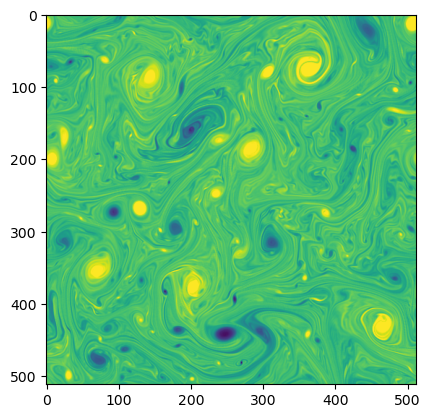

In [5]:
# define calculator
device = 'gpu' # 'cpu'
M = 256
N = M
J = 8
L = 4
filters_set = ST.FiltersSet(M=M, N=N, J=J, L=L).generate_morlet(
    if_save=False, save_dir=None, precision='single'
)

ST_calculator = ST.ST_2D(filters_set, J, L, device=device, weight=None)
image_torch = torch.from_numpy(image)
if device=='gpu':
  image_torch = image_torch.cuda()

plt.imshow(image[0], vmax=np.percentile(image, 99))
plt.show()

ST+hist7


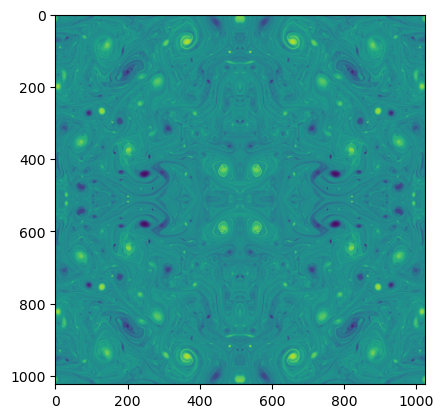

0
loss:  tensor(12411475., device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(12410475., device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(12411450., device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(12410450., device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(8723301., device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(8722598., device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(5583364., device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(5582914., device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(3573956.5000, device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(3573668.5000, device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(2288022.2500, device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(2287838., device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(1465031.5000, device='cuda:0', grad_fn=<AddBackward0>)
loss_hist:  tensor(1464913.5000, device='cuda:0', grad_fn=<MulBackward0>)
0
loss:  tensor(9

In [14]:
for coef in [
    'ST+hist7',
]:
    print(coef)
    device = 'gpu'
    N_realization = 1
    image_init = None#synthesised_image#
    J = 8
    L = 4
    torch.autograd.set_detect_anomaly(False)

    for random_seed in [987]:
        synthesised_image = image_synthesis(
            image[:N_realization],
            J=J, L=L,
            N_realization = N_realization,
            learnable_param_list = [
                (2, 2e-1),
            ],
            savedir = None,
            device = device,
            coef = coef,
            random_seed = random_seed,
            starting_power_factor = 1,
            starting_image = image_init,
            flip=1,
            optim_mode='LBFGS',
            filter='morlet'
        )
        # np.save(save_dir +'synthesised_turing_pattern.npy', synthesised_image)
        print(image.std(),  synthesised_image.std())

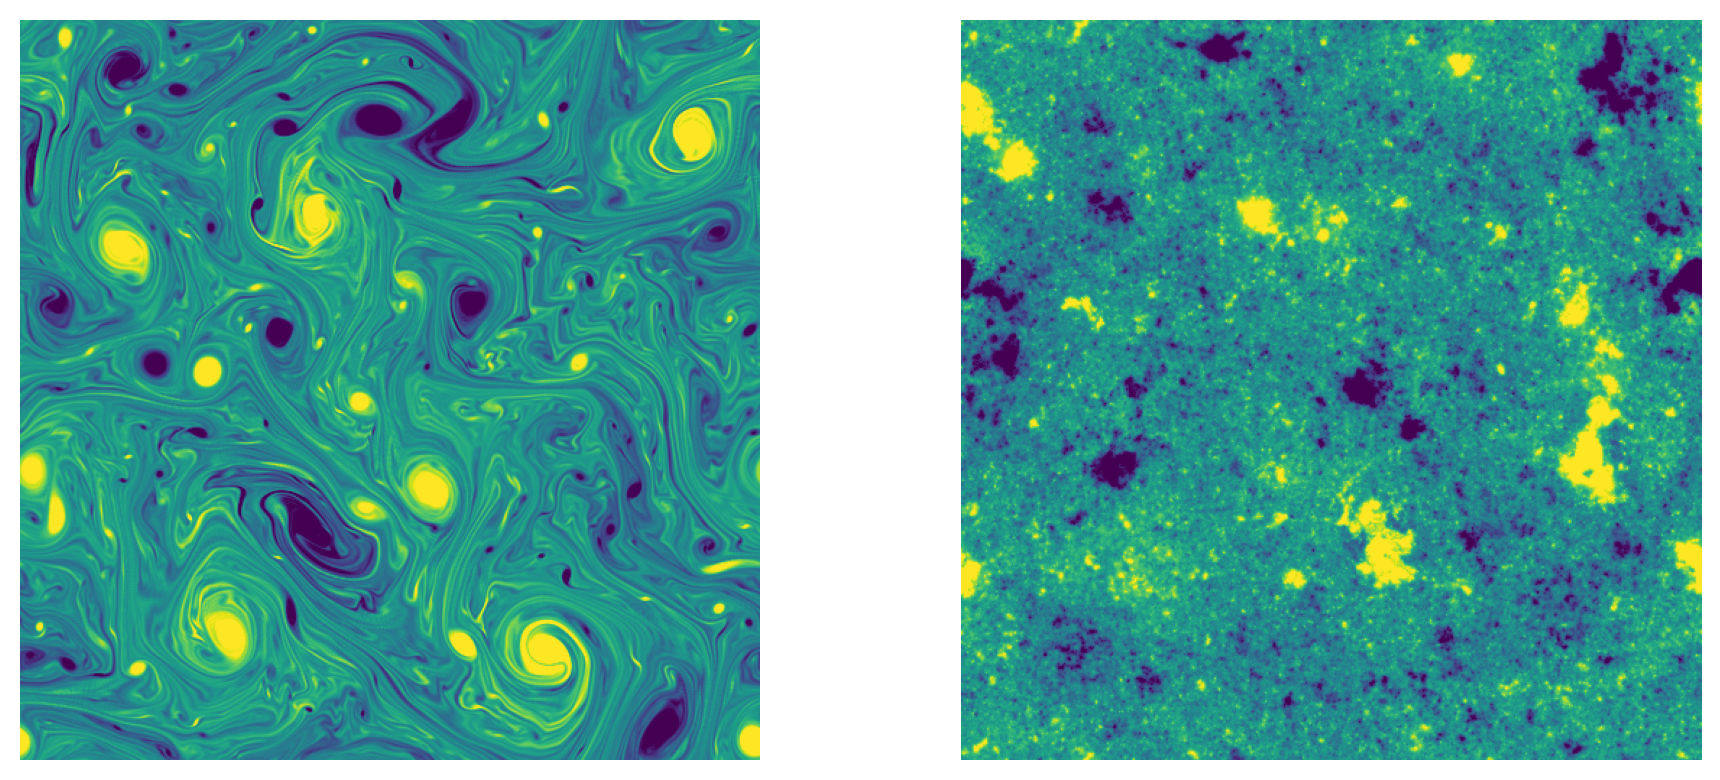

In [17]:
# ── Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
axes[0].imshow(image[0], cmap='viridis', vmin = -0.15, vmax = 0.15, origin='lower')
axes[0].axis("off")
axes[1].imshow(synthesised_image[0], cmap='viridis', vmin = -0.15, vmax = 0.15, origin='lower')
axes[1].axis("off")
plt.tight_layout()
plt.show()